# 01 — Preparación y visualización de CT

## Objetivo

Leer el par SDCT/LDCT, verificar su geometría y obtener una escala compartida en HU.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

DICOM → HU con slope/intercept propios → comprobación de posición, orientación y PixelSpacing → min–max de SDCT aplicado a ambas entradas.

**Procedencia:** sdct_ldct_sinograma_gaussiano.ipynb, celdas 8–14; Hito-1/reproducir.py: leer_hu/calcular; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

In [2]:
pair = prepare_pair(config)
show_table([{'imagen': 'SDCT', 'filas': pair['sdct_hu'].shape[0], 'columnas': pair['sdct_hu'].shape[1],
             'min_HU': float(pair['sdct_hu'].min()), 'max_HU': float(pair['sdct_hu'].max())},
            {'imagen': 'LDCT', 'filas': pair['ldct_hu'].shape[0], 'columnas': pair['ldct_hu'].shape[1],
             'min_HU': float(pair['ldct_hu'].min()), 'max_HU': float(pair['ldct_hu'].max())}])

imagen,filas,columnas,min_HU,max_HU
SDCT,512,512,-1024,1616
LDCT,512,512,-1024,1820


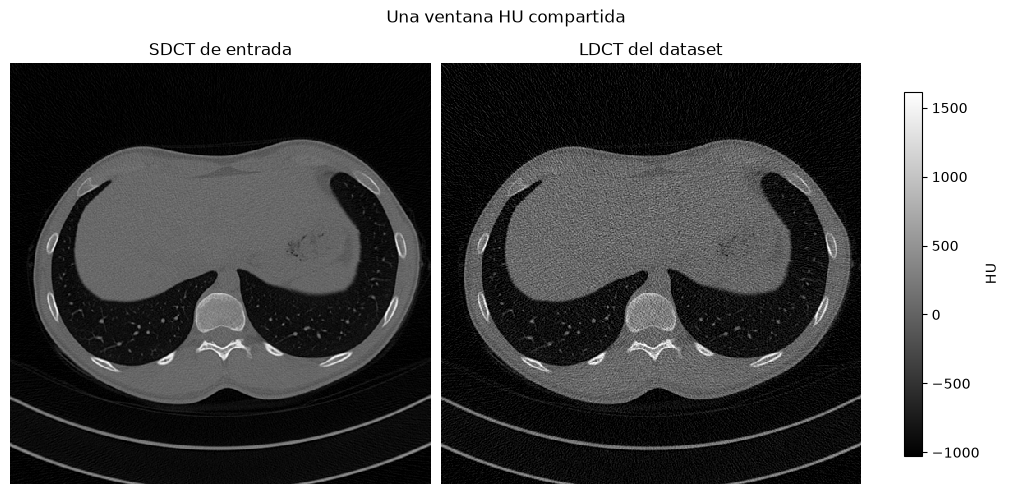

In [3]:
from src.visualization import image_panels
fig = image_panels([pair['sdct_hu'], pair['ldct_hu']], ['SDCT de entrada', 'LDCT del dataset'],
                   limits=(pair['scale'].minimum, pair['scale'].maximum), unit='HU',
                   title='Una ventana HU compartida')
finish_figure(fig, output_path('figures', '01_ct_pair.png'))

La LDCT se normaliza con los extremos SDCT. Los valores fuera de [0,1] se conservan en los cálculos.

In [4]:
from src.normalization import denormalize_image
np.testing.assert_allclose(denormalize_image(pair['sdct'], pair['scale']), pair['sdct_hu'])
np.testing.assert_allclose(denormalize_image(pair['ldct'], pair['scale']), pair['ldct_hu'])
show_table([{'dato': 'normalización compartida', 'min_SDCT_HU': pair['scale'].minimum,
             'max_SDCT_HU': pair['scale'].maximum, 'rango_HU': pair['scale'].range}])

dato,min_SDCT_HU,max_SDCT_HU,rango_HU
normalización compartida,-1024,1616,2640


## Observaciones

La geometría declarada coincide, pero esto no realiza registro anatómico. Se conserva la matriz 512×512 sin reorientar ni remuestrear. SDCT y LDCT ya contienen el ruido de sus respectivas adquisiciones.